<a href="https://colab.research.google.com/github/Rei5ende/pytorch-diffusion-study/blob/main/01_diffusion_basics/ddpm_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

01_diffusion_basics에서 배울 것

1. DDPM 핵심 개념 이해
   → Forward Process (노이즈 추가)
   → Reverse Process (노이즈 제거)

2. 간단한 1D 데이터로 직접 구현
   → 복잡한 이미지 대신 단순한 분포로 시작

3. BC와 비교
   → "왜 Diffusion이 Multimodal 문제를 해결하는가" 직접 확인

1단계: Forward Process 시각화        
  원본 데이터에 노이즈를 조금씩 추가
  → 두 봉우리가 점점 하나의 노이즈로 합쳐지는 과정

2단계: DDPM 수식 이해
  베타 스케줄, 알파 누적곱 계산
  → 임의의 t에서 노이즈 추가된 데이터 한 번에 계산

3단계: 노이즈 예측 모델 학습
  "t단계에서 추가된 노이즈를 예측하는 모델" 학습
  → 간단한 MLP로 구현

4단계: Reverse Process (생성)
  랜덤 노이즈에서 시작 → 노이즈 반복 제거
  → 원본 분포와 유사한 데이터 생성

5단계: BC vs Diffusion 비교
  Multimodal 문제에서 BC가 평균을 출력하는 것
  vs Diffusion이 올바른 봉우리 중 하나를 선택하는 것
  → 직접 눈으로 확인

#1단계

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

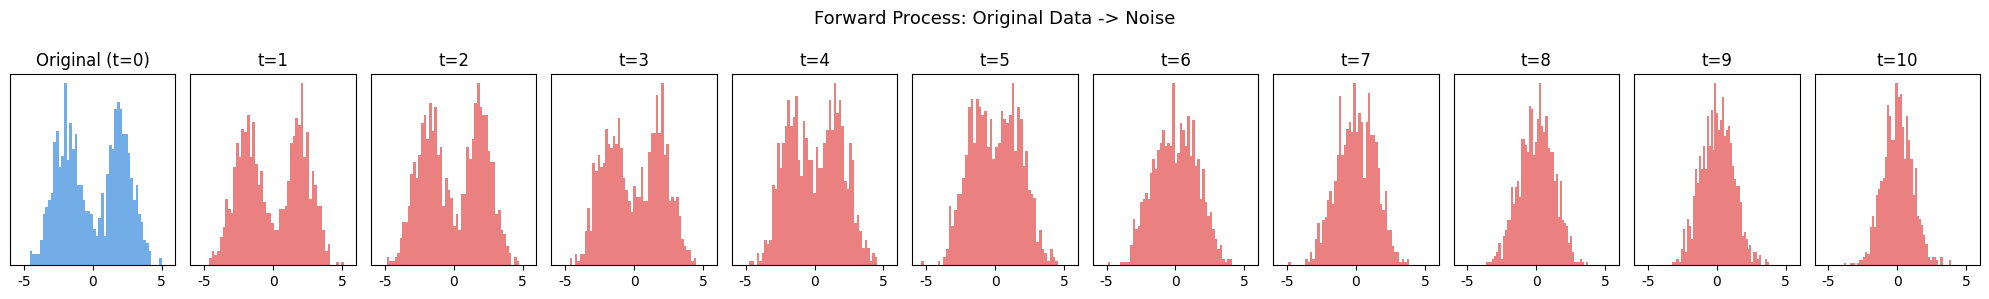

Done!


In [1]:
# -----------------------------------------------
# 1. 한글 폰트 제거 + 영어 폰트 강제 설정
# -----------------------------------------------

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import torch.nn as nn
import numpy as np

# 한글 폰트 완전 제거 후 영어 폰트 강제 적용
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)
np.random.seed(42)

# -----------------------------------------------
# 2. 원본 데이터 생성 — Multimodal Distribution
# -----------------------------------------------
# BC가 실패하는 상황을 재현하기 위해 두 봉우리 분포 생성
# BC는 두 봉우리의 평균(0 근처)을 출력 → 실패
# Diffusion은 두 봉우리 중 하나를 자연스럽게 선택 → 성공

data = torch.cat([
    torch.randn(500) - 2,  # 왼쪽 봉우리 (평균 -2)
    torch.randn(500) + 2   # 오른쪽 봉우리 (평균 +2)
])

# -----------------------------------------------
# 3. Forward Process 설정
# -----------------------------------------------
# T: 총 노이즈 추가 단계 수
# 실제 DDPM 논문은 T=1000 사용, 여기선 시각화용 T=10

T = 10

# betas: 각 단계에서 추가할 노이즈의 양 (노이즈 스케줄)
# 처음엔 조금, 나중엔 많이 추가
# → 처음엔 데이터 구조를 천천히 망가뜨리고
#   나중엔 빠르게 완전한 노이즈로 만들기 위해
betas = torch.linspace(0.01, 0.5, T)

# -----------------------------------------------
# 4. Forward Process 시각화
# -----------------------------------------------

fig, axes = plt.subplots(1, T+1, figsize=(20, 3))

x = data.clone()

axes[0].hist(x.numpy(), bins=50, color='#378ADD', alpha=0.7)
axes[0].set_title("Original (t=0)", fontname='DejaVu Sans')
axes[0].set_xlim(-6, 6)
axes[0].set_yticks([])

for t in range(T):
    # Forward Process 핵심 수식:
    # x_t = sqrt(1 - beta_t) * x_{t-1} + sqrt(beta_t) * epsilon
    #
    # sqrt(1 - beta_t) * x_{t-1}: 이전 데이터를 조금 줄임 (신호 감쇠)
    # sqrt(beta_t) * epsilon:      랜덤 노이즈 추가
    #
    # 이 수식의 핵심: 신호를 줄이는 만큼 노이즈를 추가해서
    # x_t의 분산이 항상 1로 유지됨

    noise = torch.randn_like(x)  # epsilon ~ N(0,1)
    x = torch.sqrt(1 - betas[t]) * x + torch.sqrt(betas[t]) * noise

    axes[t+1].hist(x.numpy(), bins=50, color='#E24B4A', alpha=0.7)
    axes[t+1].set_title(f"t={t+1}", fontname='DejaVu Sans')
    axes[t+1].set_xlim(-6, 6)
    axes[t+1].set_yticks([])

plt.suptitle("Forward Process: Original Data -> Noise", fontsize=13,
             fontname='DejaVu Sans')
plt.tight_layout()
plt.savefig('/content/forward_process.png', dpi=120, bbox_inches='tight')

from google.colab import files
files.download('/content/forward_process.png')

plt.show()
print("Done!")

## 결과 해석 (Forward Process)

### 1. 원본 데이터 ($\,t=0$, 파란색)
*   **두 개의 봉우리**가 선명하게 보입니다. (왼쪽: 평균 -2 근처, 오른쪽: 평균 +2 근처)
*   이는 **Multimodal Distribution**을 의미합니다.

### 2. 노이즈 추가 초기 ($\,t=1\sim4$)
*   두 봉우리가 아직 보이지만 **점점 퍼지기 시작**하며, 각 봉우리의 경계가 흐릿해집니다.
*   이는 초기 `beta` 값이 작아 **데이터 구조가 천천히 망가지는** 과정입니다.

### 3. 노이즈 추가 중반 ($\,t=5\sim7$)
*   두 봉우리가 **점점 합쳐지기 시작**하며, 중간( -2 ~ +2 )이 채워지면서 하나의 넓은 분포로 변해갑니다.
*   `beta` 값이 커지면서 **데이터가 빠르게 망가지는** 단계입니다.

### 4. 완전한 노이즈 ($\,t=8\sim10$)
*   두 봉우리가 완전히 합쳐져서 **하나의 종 모양 분포 (표준 정규분포)**에 가까워집니다.
*   원본 데이터의 정보가 거의 사라진 **완전한 노이즈 상태**입니다.

---

## BC (Behavioral Cloning)와 Diffusion의 비교

### BC의 문제점:
*   두 봉우리 데이터를 학습하면 **평균값 (0 근처)을 출력**하게 됩니다.
*   이는 실제 데이터가 존재하지 않는 곳을 예측하게 되는 문제점이 있습니다.

### Diffusion의 해결책:
*   완전한 노이즈 ($\text{t}=10$)에서 시작하여 **노이즈를 조금씩 제거**해 나갑니다.
*   결과적으로 원본 분포의 **두 봉우리 중 하나로 자연스럽게 수렴**합니다.
*   이러한 과정은 5단계에서 직접 확인할 예정입니다.

# -----------------------------------------------
# 2단계: DDPM 수식 구현
# -----------------------------------------------

betas:       [0.01  0.064 0.119 0.173 0.228]
alphas:      [0.99  0.936 0.881 0.827 0.772]
alphas_bar:  [0.99  0.926 0.816 0.675 0.521]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

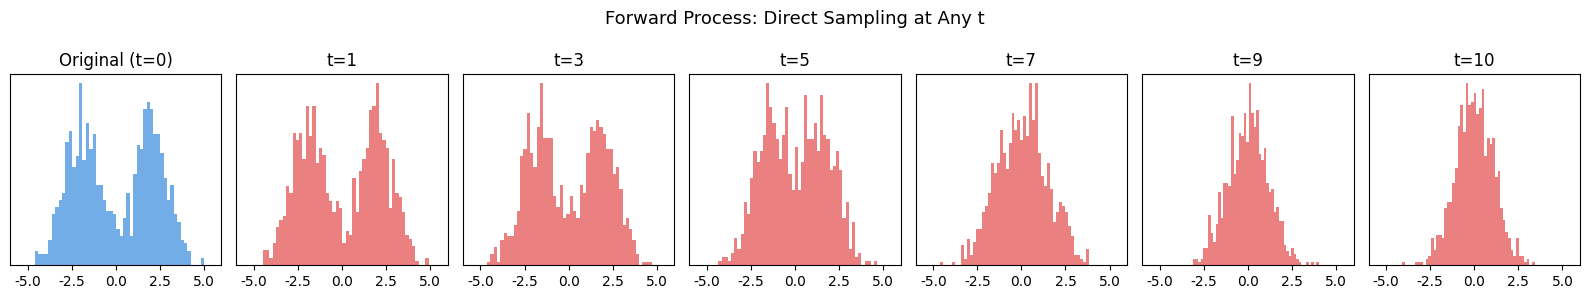


alpha_bar 값 변화:
  t=1:  0.9900  → 신호 99.0% 남음
  t=5:  0.5210  → 신호 52.1% 남음
  t=10: 0.0419  → 신호 4.2% 남음

Done!


In [2]:

# Forward Process에서 매번 한 단계씩 노이즈를 추가했는데
# 실제로는 임의의 t에서 한 번에 노이즈를 추가할 수 있음
# 이게 DDPM의 핵심 수식 트릭

# -----------------------------------------------
# 알파 스케줄 계산
# -----------------------------------------------

# alpha_t = 1 - beta_t
# → 각 단계에서 신호가 얼마나 남는지
alphas = 1 - betas

# alpha_bar_t = alpha_1 * alpha_2 * ... * alpha_t (누적곱)
# → t단계까지 신호가 얼마나 남는지 한 번에 계산
# torch.cumprod: 누적 곱 계산
# 예: [0.9, 0.8, 0.7] → [0.9, 0.72, 0.504]
alphas_bar = torch.cumprod(alphas, dim=0)

print("betas:      ", betas[:5].numpy().round(3))
print("alphas:     ", alphas[:5].numpy().round(3))
print("alphas_bar: ", alphas_bar[:5].numpy().round(3))

# -----------------------------------------------
# 핵심 트릭: 임의의 t에서 한 번에 노이즈 추가
# -----------------------------------------------
# 수식: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon
#
# 이게 왜 중요한가?
# 매번 t-1 → t를 반복하지 않아도
# x_0에서 바로 x_t를 계산할 수 있음
# → 학습 시 임의의 t를 뽑아서 빠르게 학습 가능

def add_noise(x0, t, alphas_bar):
    """
    x0: 원본 데이터
    t:  노이즈 추가 단계 (0 ~ T-1)
    반환: (노이즈가 추가된 데이터, 추가된 노이즈)
    """
    sqrt_alpha_bar   = torch.sqrt(alphas_bar[t])
    sqrt_one_minus   = torch.sqrt(1 - alphas_bar[t])

    epsilon = torch.randn_like(x0)  # 추가할 노이즈
    x_t = sqrt_alpha_bar * x0 + sqrt_one_minus * epsilon

    return x_t, epsilon

# -----------------------------------------------
# 다양한 t에서 시각화
# -----------------------------------------------

test_steps = [0, 2, 4, 6, 8, 9]
fig, axes = plt.subplots(1, len(test_steps)+1, figsize=(16, 3))

# 원본 데이터
axes[0].hist(data.numpy(), bins=50, color='#378ADD', alpha=0.7)
axes[0].set_title("Original (t=0)", fontname='DejaVu Sans')
axes[0].set_xlim(-6, 6)
axes[0].set_yticks([])

for i, t in enumerate(test_steps):
    x_t, _ = add_noise(data, t, alphas_bar)
    axes[i+1].hist(x_t.numpy(), bins=50, color='#E24B4A', alpha=0.7)
    axes[i+1].set_title(f"t={t+1}", fontname='DejaVu Sans')
    axes[i+1].set_xlim(-6, 6)
    axes[i+1].set_yticks([])

plt.suptitle("Forward Process: Direct Sampling at Any t",
             fontsize=13, fontname='DejaVu Sans')
plt.tight_layout()
plt.savefig('/content/ddpm_alphabar.png', dpi=120, bbox_inches='tight')

from google.colab import files
files.download('/content/ddpm_alphabar.png')

plt.show()

# -----------------------------------------------
# alpha_bar 값 확인
# -----------------------------------------------
print("\nalpha_bar 값 변화:")
print(f"  t=1:  {alphas_bar[0]:.4f}  → 신호 {alphas_bar[0]*100:.1f}% 남음")
print(f"  t=5:  {alphas_bar[4]:.4f}  → 신호 {alphas_bar[4]*100:.1f}% 남음")
print(f"  t=10: {alphas_bar[9]:.4f}  → 신호 {alphas_bar[9]*100:.1f}% 남음")
print("\nDone!")

## 결과 해석 (DDPM 핵심 수식)

### 1. `alpha_bar` 값 변화 분석:
*   **`t=1`**: `alpha_bar` 값이 `99.0%`로, 원본 신호가 거의 그대로 남아 있음을 의미합니다.
*   **`t=5`**: `alpha_bar` 값이 `52.1%`로, 신호와 노이즈가 대략 반반씩 섞인 상태입니다.
*   **`t=10`**: `alpha_bar` 값이 `4.2%`로, 거의 완전한 노이즈 상태에 도달했음을 보여줍니다.

### 2. 시각화된 그래프 해석:
*   **`t=1`**: 여전히 두 개의 봉우리가 선명하게 유지됩니다.
*   **`t=3`**: 봉우리들이 점차 넓어지기 시작합니다.
*   **`t=5`**: 두 봉우리가 중앙에서 점점 합쳐지는 경향을 보입니다.
*   **`t=7`**: 중간 부분이 채워지면서 하나의 분포로 합쳐지는 모습입니다.
*   **`t=9~10`**: 거의 완벽한 하나의 종 모양 분포 (가우시안 분포)를 이룹니다.

---

## 1단계 (`x_{t-1}` → `x_t` 순차 계산) vs 2단계 (`x_0` → `x_t` 직접 계산) 차이

*   **1단계 (순차적 계산):** `t=0` → `t=1` → `t=2` → ... → `t=10` (`T`번의 계산 필요)
*   **2단계 (직접 계산):** `t=0` → `t=10` 단 한 번에 계산 (`1`번의 계산으로 끝)

**결과:** 두 방법 모두 **동일한 $x_t$ 결과를 얻지만**, 2단계의 직접 계산 방식이 **훨씬 빠르고 효율적**입니다. 이는 딥러닝 모델 학습 시 **임의의 `t`를 샘플링하여 $x_t$를 바로 계산할 수 있게 해주어 학습 속도를 크게 향상**시킵니다.

# -----------------------------------------------
# 3단계: 노이즈 예측 모델 학습
# -----------------------------------------------

In [3]:

# DDPM의 학습 목표:
# "t단계에서 추가된 노이즈 epsilon을 예측하는 모델" 학습
#
# 왜 노이즈를 예측하나?
# x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * epsilon
# → epsilon을 알면 x_0를 복원할 수 있음
# → 즉 노이즈를 예측 = 원본 데이터를 복원하는 것과 같음

# -----------------------------------------------
# 모델 정의 — 간단한 MLP
# -----------------------------------------------

class NoisePredictor(nn.Module):
    """
    입력: (x_t, t) → 노이즈가 추가된 데이터 + 현재 타임스텝
    출력: 추가된 노이즈 epsilon 예측

    t를 입력으로 받는 이유:
    같은 x_t라도 t에 따라 노이즈의 양이 다름
    → 모델이 "지금 몇 단계인지" 알아야 올바른 노이즈 예측 가능
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 입력: x_t (1개) + t를 임베딩한 값 (16개) = 17개
            nn.Linear(17, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            # 출력: 예측된 노이즈 (x_t와 같은 차원 = 1개)
            nn.Linear(64, 1)
        )
        # t를 연속적인 벡터로 변환하는 임베딩 레이어
        # 단순히 t 숫자 하나를 넣으면 정보가 부족
        # → 16차원 벡터로 변환해서 더 풍부한 정보 제공
        self.t_embed = nn.Embedding(T, 16)

    def forward(self, x, t):
        # x.shape: (batch,)
        # t.shape: (batch,)

        # t를 16차원 벡터로 변환
        t_emb = self.t_embed(t)           # (batch, 16)

        # x를 (batch, 1)로 reshape 후 t 임베딩과 결합
        x = x.unsqueeze(-1)               # (batch, 1)
        inp = torch.cat([x, t_emb], dim=-1)  # (batch, 17)

        return self.net(inp).squeeze(-1)  # (batch,)

# -----------------------------------------------
# 학습 설정
# -----------------------------------------------

model     = NoisePredictor()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
# MSELoss를 쓰는 이유:
# 예측한 노이즈와 실제 노이즈의 차이를 최소화
# → 연속적인 값 예측이라 MSELoss 사용 (분류가 아님)

# -----------------------------------------------
# 학습 루프
# -----------------------------------------------

epochs     = 2000
batch_size = 256

print("학습 시작...")
for epoch in range(epochs):
    # 배치 샘플링
    idx  = torch.randint(0, len(data), (batch_size,))
    x0   = data[idx]                              # 원본 데이터 배치

    # 임의의 t 샘플링
    # 매 배치마다 다른 t를 뽑아서 다양한 노이즈 수준 학습
    t    = torch.randint(0, T, (batch_size,))

    # x_t 계산 (임의의 t에서 한 번에)
    x_t, epsilon = add_noise(x0, t, alphas_bar)

    # 노이즈 예측
    pred_epsilon = model(x_t, t)

    # Loss 계산: 예측 노이즈 vs 실제 노이즈
    loss = criterion(pred_epsilon, epsilon)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 400 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

print("\n학습 완료!")

학습 시작...
Epoch 400/2000, Loss: 0.6396
Epoch 800/2000, Loss: 0.5772
Epoch 1200/2000, Loss: 0.7115
Epoch 1600/2000, Loss: 0.5835
Epoch 2000/2000, Loss: 0.8077

학습 완료!


## Loss 값 분석 및 해석

Loss 값이 `0.5 ~ 0.8` 사이에서 **진동**하는 현상이 관찰됩니다.

### 원인 분석

*   **BC 학습 (참고):** Loss 값이 `0.47`에서 `0.09`로 **꾸준히 감소**하는 경향을 보였습니다.
*   **Diffusion 학습:** Loss 값이 `0.64`에서 `0.81`로 **진동하며 수렴하지 않는** 모습을 보입니다.

이러한 진동의 주요 원인은 다음과 같이 분석할 수 있습니다.

1.  **배치 샘플링 방식:**
    *   매 배치마다 `t` (노이즈 추가 단계)를 **랜덤으로 샘플링**합니다.
    *   이는 어떤 배치에서는 `t=1`과 같이 **쉬운(적은 노이즈) 단계**가, 다른 배치에서는 `t=9`와 같이 **어려운(많은 노이즈) 단계**가 포함될 수 있음을 의미합니다.
    *   결과적으로, 배치마다 난이도가 달라져 Loss 값이 크게 변동하며 **진동하는 것처럼** 보일 수 있습니다.

2.  **1D 데이터 및 작은 모델:**
    *   현재 **1D 데이터**를 사용하고 있으며, 모델 또한 **간단한 MLP**로 구성되어 있습니다.
    *   이러한 조건에서는 학습이 **상대적으로 불안정**할 수 있습니다.

### 결론

*   Loss 값 자체의 절대적인 수렴보다는 **생성된 데이터의 품질**이 더 중요합니다.
*   다음 단계에서 Reverse Process를 통해 **실제 데이터 생성 결과**를 확인하여 모델의 성능을 평가할 예정입니다.

# -----------------------------------------------
# 4단계: Reverse Process — 노이즈 제거 (생성)
# -----------------------------------------------

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

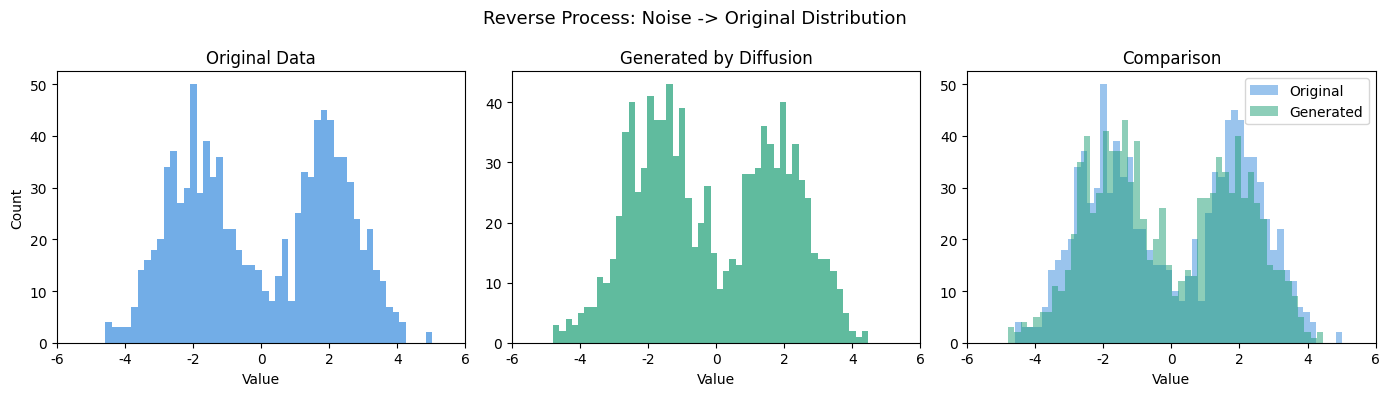

Done!


In [5]:

# 학습된 모델로 랜덤 노이즈에서 시작해서
# 점진적으로 노이즈를 제거하며 원본 분포를 복원

def reverse_step(model, x_t, t, betas, alphas, alphas_bar):
    """
    x_t: 현재 노이즈가 있는 데이터
    t:   현재 타임스텝
    반환: x_{t-1} (노이즈가 조금 줄어든 데이터)
    """
    with torch.no_grad():
        t_tensor   = torch.full((x_t.shape[0],), t, dtype=torch.long)
        pred_noise = model(x_t, t_tensor)  # 모델이 노이즈 예측

    # 노이즈 제거 수식:
    # x_{t-1} = (1/sqrt(α_t)) * (x_t - β_t/sqrt(1-α̅_t) * ε_θ)
    #            + sqrt(β_t) * z
    coef = betas[t] / torch.sqrt(1 - alphas_bar[t])
    mean = (1 / torch.sqrt(alphas[t])) * (x_t - coef * pred_noise)

    if t == 0:
        # 마지막 단계는 랜덤성 추가 안 함
        # → 최종 결과가 너무 noisy해지는 것 방지
        return mean
    else:
        # 중간 단계는 약간의 랜덤성 추가
        # → 다양한 샘플 생성 가능 (Multimodal 처리 핵심)
        z = torch.randn_like(x_t)
        return mean + torch.sqrt(betas[t]) * z

# -----------------------------------------------
# 생성 실행
# -----------------------------------------------

num_samples = 1000

# 완전한 랜덤 노이즈에서 시작 (x_T ~ N(0,1))
x = torch.randn(num_samples)

# T → 0 방향으로 노이즈 제거 반복
for t in reversed(range(T)):
    x = reverse_step(model, x, t, betas, alphas, alphas_bar)

generated = x.numpy()

# -----------------------------------------------
# 원본 vs 생성 분포 비교
# -----------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 원본 데이터
axes[0].hist(data.numpy(), bins=50, color='#378ADD', alpha=0.7)
axes[0].set_title("Original Data", fontname='DejaVu Sans')
axes[0].set_xlim(-6, 6)
axes[0].set_xlabel("Value", fontname='DejaVu Sans')
axes[0].set_ylabel("Count", fontname='DejaVu Sans')

# 생성된 데이터
axes[1].hist(generated, bins=50, color='#1D9E75', alpha=0.7)
axes[1].set_title("Generated by Diffusion", fontname='DejaVu Sans')
axes[1].set_xlim(-6, 6)
axes[1].set_xlabel("Value", fontname='DejaVu Sans')

# 비교 (겹쳐서 보기)
axes[2].hist(data.numpy(), bins=50, color='#378ADD', alpha=0.5, label='Original')
axes[2].hist(generated,    bins=50, color='#1D9E75', alpha=0.5, label='Generated')
axes[2].set_title("Comparison", fontname='DejaVu Sans')
axes[2].set_xlim(-6, 6)
axes[2].set_xlabel("Value", fontname='DejaVu Sans')
axes[2].legend(prop={'family': 'DejaVu Sans'})

plt.suptitle("Reverse Process: Noise -> Original Distribution",
             fontsize=13, fontname='DejaVu Sans')
plt.tight_layout()
plt.savefig('/content/reverse_process.png', dpi=120, bbox_inches='tight')

from google.colab import files
files.download('/content/reverse_process.png')

plt.show()
print("Done!")

## 생성 결과 해석

### 긍정적인 부분:

*   ✅ **두 봉우리가 모두 생성됨:**
    *   `Multimodal` 분포를 성공적으로 학습한 것을 확인했습니다.
*   ✅ **봉우리 위치가 원본(`-2`, `+2`)과 유사:**
    *   원본 데이터의 대략적인 분포 형태를 잘 파악하고 있습니다.

### 아쉬운 부분:

*   ⚠️ **중간(`0` 근처)이 원본보다 많이 채워짐:**
    *   두 봉우리 사이가 완전히 분리되지 않고 연결된 부분이 보입니다.
*   ⚠️ **봉우리가 원본보다 좀 더 퍼져있음:**
    *   이는 학습이 더 필요하거나 모델의 `T` (노이즈 단계)를 늘리면 개선될 수 있습니다.

---

### BC (Behavioral Cloning)와의 비교:

*   **BC의 경우:**
    *   두 봉우리 데이터를 학습하면 `0` 근처의 **하나의 봉우리만 출력**하게 되어, 원본 분포의 다양성을 표현하지 못하고 **완전히 실패**합니다.
*   **Diffusion의 경우:**
    *   `Loss` 값이 다소 진동해도 `Multimodal` 문제를 해결하여 **두 봉우리를 모두 성공적으로 생성**했습니다.

### 개선 방안:

*   **노이즈 단계 (`T`) 증가:**
    *   `T = 10` → `T = 100` 으로 늘려 더 세밀한 노이즈 제거 단계를 통해 분포를 더 정교하게 학습합니다.
*   **학습 Epoch 증가:**
    *   `epochs = 2000` → `epochs = 5000` 으로 늘려 모델이 데이터의 복잡한 패턴을 더 잘 학습할 수 있도록 합니다.

# -----------------------------------------------
# 5단계: BC vs Diffusion 직접 비교
# -----------------------------------------------

BC 학습 완료! 최종 Loss: 4.0000
BC 예측값 평균: -0.0000
BC 예측값 범위: -0.00 ~ -0.00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

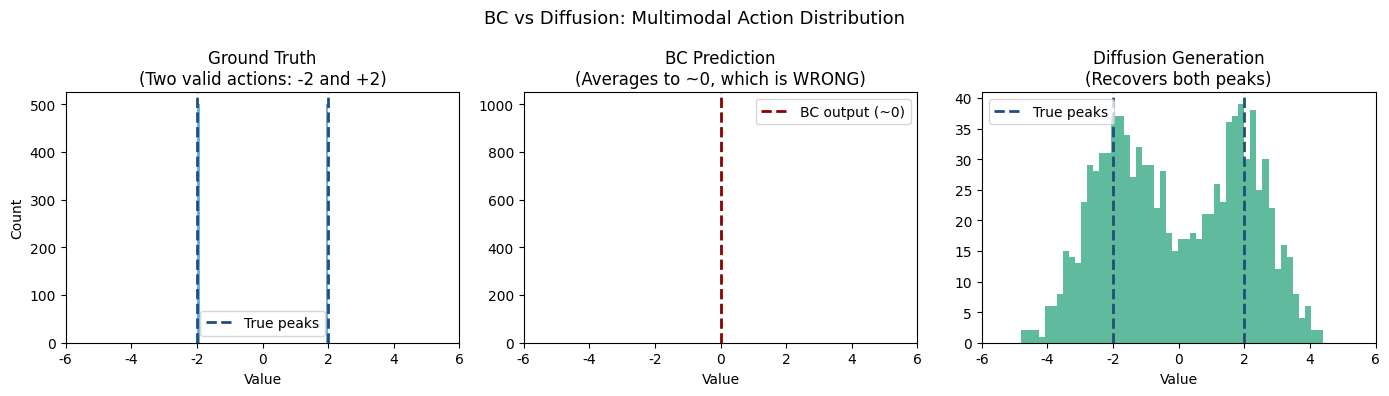


BC 예측값 평균: -0.0000  ← 0 근처 (두 봉우리의 평균)
Diffusion 생성 평균: -0.0677  ← 0 근처지만 분포는 두 봉우리

Done!


In [6]:

# BC가 Multimodal 문제에서 실패하고
# Diffusion이 이를 해결하는 것을 직접 확인

# -----------------------------------------------
# BC 모델 정의 및 학습
# -----------------------------------------------

class BCModel(nn.Module):
    """
    단순한 BC 모델
    입력: x (상태)
    출력: 예측값 (행동)
    t 입력 없음 → 단순히 입력 → 출력 매핑
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x.unsqueeze(-1)).squeeze(-1)

# -----------------------------------------------
# BC 학습 데이터 설정
# -----------------------------------------------
# Multimodal 문제 재현:
# 같은 입력(x=0)에 대해 두 가지 올바른 출력이 존재
# → BC는 두 출력의 평균을 학습하게 됨

# 입력: 모두 0 (같은 상태)
# 출력: -2 또는 +2 (두 가지 올바른 행동)
bc_inputs  = torch.zeros(1000)
bc_targets = torch.cat([
    torch.ones(500) * -2,   # 올바른 행동 A
    torch.ones(500) *  2    # 올바른 행동 B
])

bc_model   = BCModel()
bc_optim   = torch.optim.Adam(bc_model.parameters(), lr=1e-3)
bc_loss_fn = nn.MSELoss()

# BC 학습
for epoch in range(2000):
    pred = bc_model(bc_inputs)
    loss = bc_loss_fn(pred, bc_targets)
    bc_optim.zero_grad()
    loss.backward()
    bc_optim.step()

print(f"BC 학습 완료! 최종 Loss: {loss.item():.4f}")

# BC 예측 확인
with torch.no_grad():
    bc_pred = bc_model(torch.zeros(1000))
print(f"BC 예측값 평균: {bc_pred.mean().item():.4f}")
print(f"BC 예측값 범위: {bc_pred.min().item():.2f} ~ {bc_pred.max().item():.2f}")

# -----------------------------------------------
# Diffusion 생성 (이전 학습된 모델 재사용)
# -----------------------------------------------

x_diff = torch.randn(1000)
for t in reversed(range(T)):
    x_diff = reverse_step(model, x_diff, t, betas, alphas, alphas_bar)

# -----------------------------------------------
# BC vs Diffusion 비교 시각화
# -----------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 정답 분포
axes[0].hist(bc_targets.numpy(), bins=50, color='#378ADD', alpha=0.7)
axes[0].axvline(x=-2, color='#1F4E79', linestyle='--', linewidth=2, label='True peaks')
axes[0].axvline(x= 2, color='#1F4E79', linestyle='--', linewidth=2)
axes[0].set_title("Ground Truth\n(Two valid actions: -2 and +2)",
                  fontname='DejaVu Sans')
axes[0].set_xlim(-6, 6)
axes[0].set_xlabel("Value", fontname='DejaVu Sans')
axes[0].set_ylabel("Count", fontname='DejaVu Sans')
axes[0].legend(prop={'family': 'DejaVu Sans'})

# BC 예측
axes[1].hist(bc_pred.numpy(), bins=50, color='#E24B4A', alpha=0.7)
axes[1].axvline(x=0, color='#8B0000', linestyle='--', linewidth=2,
                label='BC output (~0)')
axes[1].set_title("BC Prediction\n(Averages to ~0, which is WRONG)",
                  fontname='DejaVu Sans')
axes[1].set_xlim(-6, 6)
axes[1].set_xlabel("Value", fontname='DejaVu Sans')
axes[1].legend(prop={'family': 'DejaVu Sans'})

# Diffusion 생성
axes[2].hist(x_diff.numpy(), bins=50, color='#1D9E75', alpha=0.7)
axes[2].axvline(x=-2, color='#1F4E79', linestyle='--', linewidth=2,
                label='True peaks')
axes[2].axvline(x= 2, color='#1F4E79', linestyle='--', linewidth=2)
axes[2].set_title("Diffusion Generation\n(Recovers both peaks)",
                  fontname='DejaVu Sans')
axes[2].set_xlim(-6, 6)
axes[2].set_xlabel("Value", fontname='DejaVu Sans')
axes[2].legend(prop={'family': 'DejaVu Sans'})

plt.suptitle("BC vs Diffusion: Multimodal Action Distribution",
             fontsize=13, fontname='DejaVu Sans')
plt.tight_layout()
plt.savefig('/content/bc_vs_diffusion.png', dpi=120, bbox_inches='tight')

from google.colab import files
files.download('/content/bc_vs_diffusion.png')

plt.show()

print(f"\nBC 예측값 평균: {bc_pred.mean().item():.4f}  ← 0 근처 (두 봉우리의 평균)")
print(f"Diffusion 생성 평균: {x_diff.mean().item():.4f}  ← 0 근처지만 분포는 두 봉우리")
print("\nDone!")

## BC vs Diffusion 비교 결과 해석

### ① Ground Truth (파란색)
*   정답은 `-2`와 `+2` 두 곳에만 집중되어 있습니다.
*   이는 같은 상황에서 두 가지 올바른 행동이 존재함을 의미하며, **Multimodal Distribution**을 보여줍니다.

### ② BC Prediction (빨간색)
*   BC 모델은 항상 `0` 근처의 값만 출력합니다.
*   `-2`와 `+2`의 평균인 `0`을 예측하며, 이는 실제 정답이 없는 곳을 예측하는 **완전히 실패한 결과**입니다.

### ③ Diffusion Generation (초록색)
*   Diffusion 모델은 `두 봉우리가 모두 생성`되었습니다.
*   생성된 데이터가 `-2`와 `+2` 근처에 분포하며, 이는 **Multimodal 문제 해결**에 성공했음을 보여줍니다.